In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "Time New Roman",
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [2]:
def load_bursting_h5(path):
    """读取 bursting h5 文件，按时间顺序拼接所有 group 中的时间序列。

    返回 dict，keys 包括 tn, tn_s, q, Energy, Enstrophy, Palinstrophy, Mx,
    Omega, CPU_time，以及（自适应步长版本）tau。
    """
    fields_scalar = ["tn", "tn_s", "q", "Energy", "Enstrophy", "Palinstrophy", "Mx", "CPU_time"]
    out = {k: [] for k in fields_scalar}
    out["Omega"] = []
    out["tau"] = []

    with h5py.File(path, "r") as f:
        # 按 group 名中的起始时间排序
        groups = sorted(f.keys(), key=lambda g: float(g.split("_")[1]))
        for g in groups:
            grp = f[g]
            for k in fields_scalar:
                out[k].append(np.asarray(grp[k]))
            out["Omega"].append(np.asarray(grp["Omega"]))
            if "tau" in grp:
                out["tau"].append(np.asarray(grp["tau"]))

    for k in list(out.keys()):
        if len(out[k]) == 0:
            del out[k]
        else:
            out[k] = np.concatenate(out[k], axis=0)
    return out


data_paths = {
    "tau=0.001":     "data/ns_ETD_mrGSAV_MS2_b_bursting_50.0_2_2.5_0.001.h5",
    "tau=0.001,g=0": "data/ns_ETD_mrGSAV_MS2_b_bursting_50.0_2_2.5_0.001_g_0.h5",
    "tau=0.001,ref": "data/ns_ETDRK4_bursting_50.0_2_2.5_0.001.h5",
    "tau=0.002":     "data/ns_ETD_mrGSAV_MS2_b_bursting_50.0_2_2.5_0.002.h5",
    "tau=0.004":     "data/ns_ETD_mrGSAV_MS2_b_bursting_50.0_2_2.5_0.004.h5",
    "vs":            "data/ns_ETD_mrGSAV_MS2_b_bursting_50.0_2_vs.h5",
}

datasets = {label: load_bursting_h5(p) for label, p in data_paths.items()}

for label, d in datasets.items():
    print(f"{label:10s}  tn_s: {d['tn_s'].shape}, Omega: {d['Omega'].shape}, "
          f"t_end={d['tn_s'][-1]:.4f}"
          + (f", tau range=[{d['tau'].min():.2e}, {d['tau'].max():.2e}]" if "tau" in d else ""))

tau=0.001   tn_s: (10001,), Omega: (10001, 128, 128), t_end=1000.0000
tau=0.001,g=0  tn_s: (10001,), Omega: (10001, 128, 128), t_end=1000.0000
tau=0.001,ref  tn_s: (10001,), Omega: (10001, 128, 128), t_end=1000.0000
tau=0.002   tn_s: (10001,), Omega: (10001, 128, 128), t_end=1000.0000
tau=0.004   tn_s: (10001,), Omega: (10001, 128, 128), t_end=1000.0000
vs          tn_s: (10001,), Omega: (10001, 128, 128), t_end=999.9908, tau range=[1.00e-05, 4.76e-03]


In [3]:
mask = datasets["tau=0.001"]["tn"]>100
np.mean(np.sqrt(datasets["tau=0.001"]["Energy"][mask]*2))*50

np.float64(1038.5531461051255)

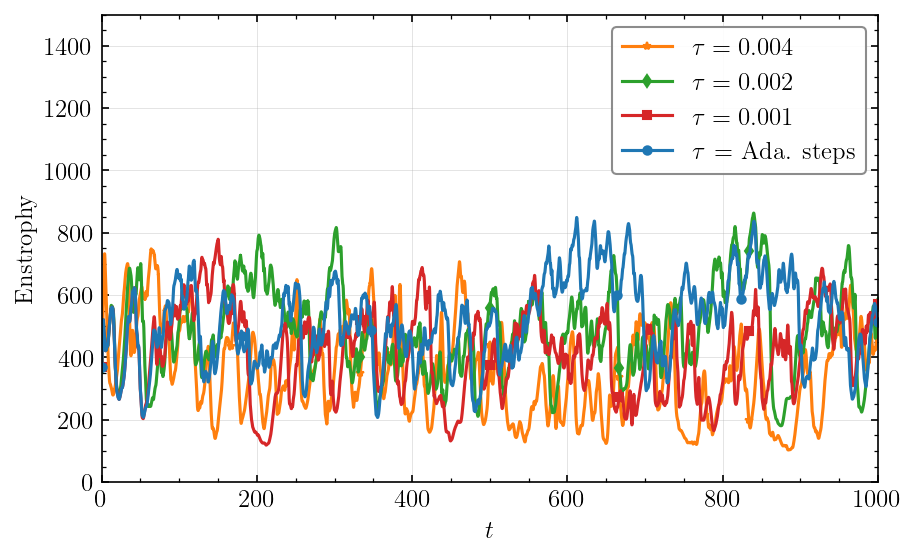

In [4]:
fig, ax = plt.subplots(figsize=(6.0, 3.6), dpi=150, constrained_layout=True)

curves = [
    ("tau=0.004", r"$\tau=0.004$", "C1", "-", "*"),
    ("tau=0.002", r"$\tau=0.002$", "C2", "-", "d"),
    ("tau=0.001", r"$\tau=0.001$", "C3", "-", "s"),
    ("vs",        r"$\tau$ = Ada. steps", "C0", "-", "o"),
]

xlim = (0, 1000)
n_markers = 6

for key, label, color, ls, mk in curves:
    d = datasets[key]
    tn = d["tn"]
    n_visible = ((tn >= xlim[0]) & (tn <= xlim[1])).sum()
    mke = max(1, n_visible // n_markers)
    ax.plot(tn, d["Enstrophy"], label=label, color=color, linestyle=ls, marker=mk, markersize=4, markevery=mke)

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Enstrophy")
ax.set_xlim(*xlim)
ax.set_ylim(0,1500)
ax.tick_params(direction="in", top=True, right=True, which="both")
ax.minorticks_on()
ax.grid(True, which="major", linewidth=0.4, alpha=0.4)
ax.legend(frameon=True, framealpha=0.9, edgecolor="0.5", loc="best")

fig.savefig("fig/enstrophy_long_time.pdf", bbox_inches="tight")
plt.show()

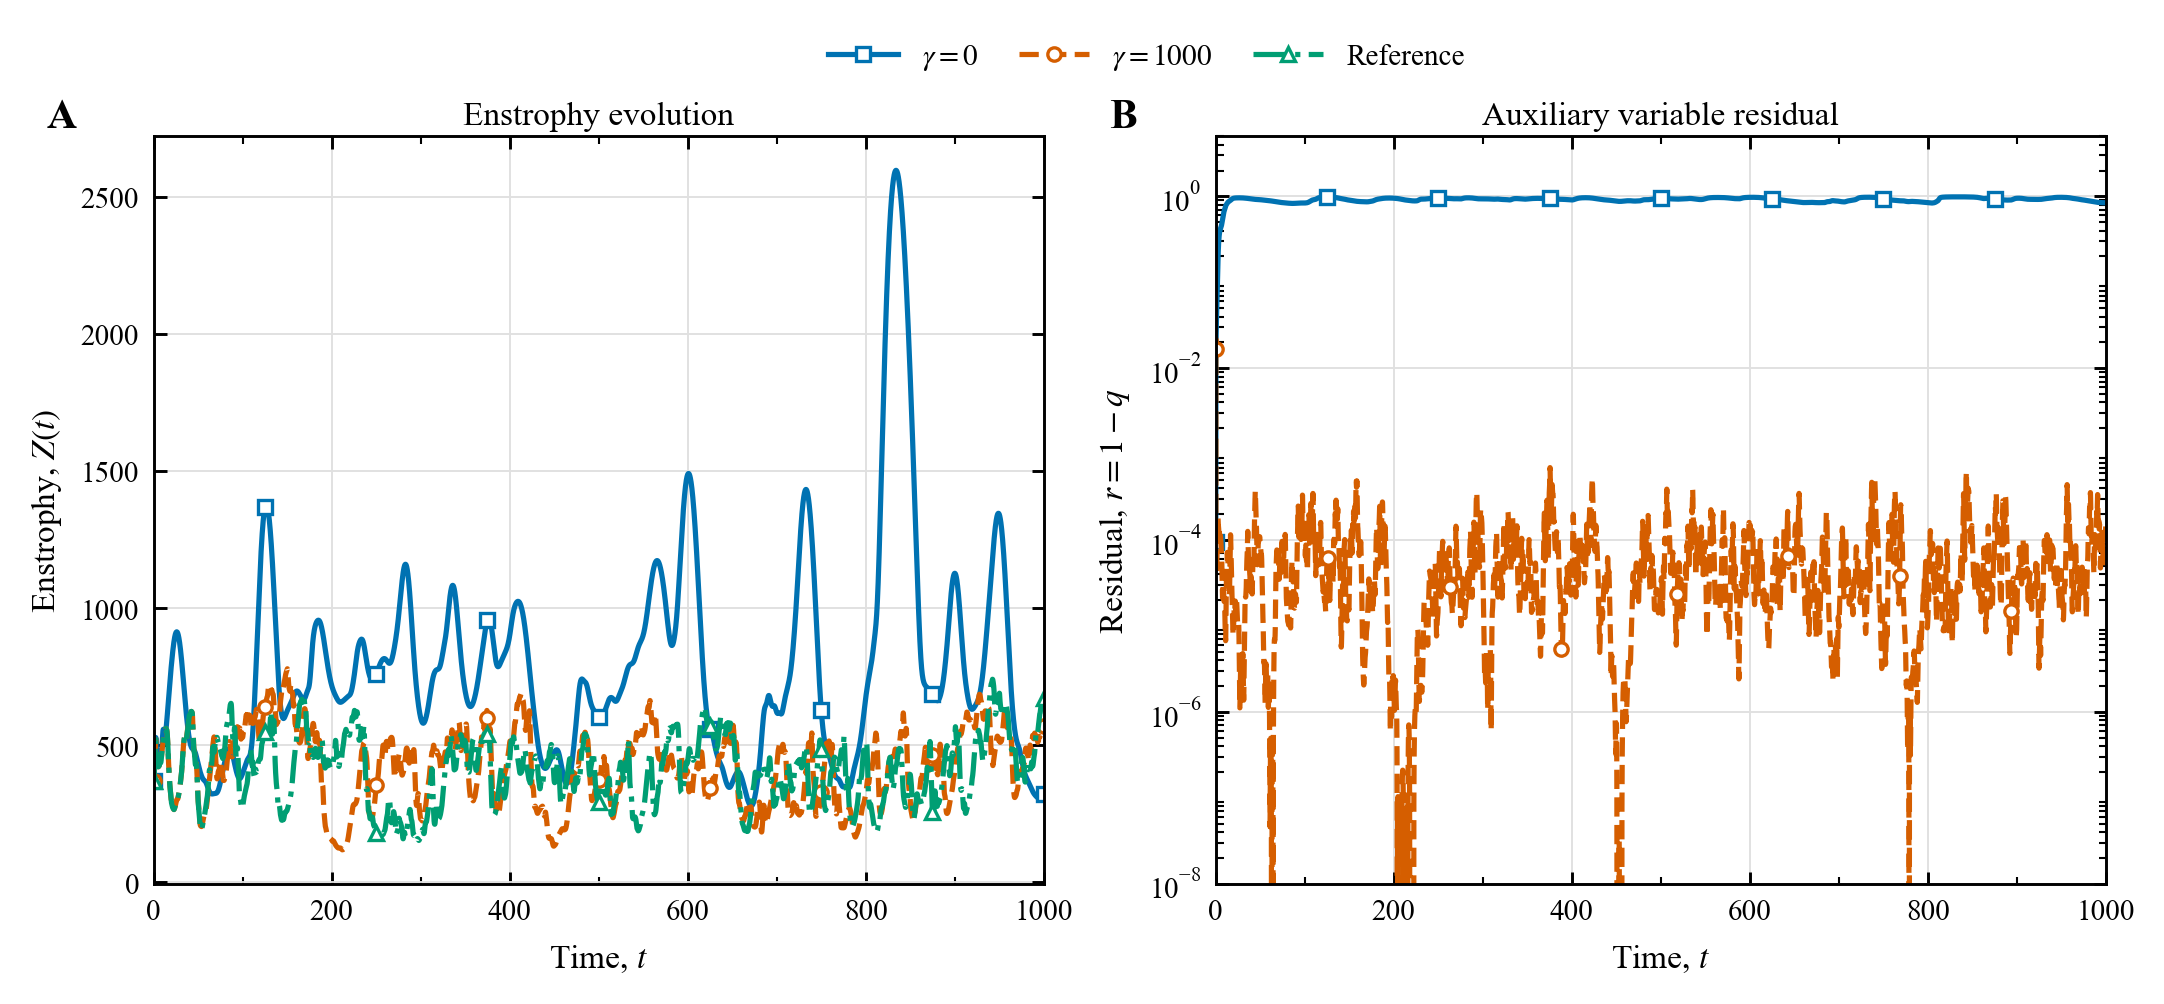

In [5]:
from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

publication_rc = {
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

# Okabe-Ito colors plus distinct line styles/markers for grayscale readability.
curves = [
    ("tau=0.001,g=0", r"$\gamma=0$", "#0072B2", "-", "s"),
    ("tau=0.001",     r"$\gamma=1000$", "#D55E00", "--", "o"),
    ("tau=0.001,ref",   "Reference", "#009E73", "-.", "^"),
]

xlim = (0, 1000)
n_markers = 8

with plt.rc_context(publication_rc):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(7.1, 3.0),
        dpi=300,
        constrained_layout=True,
        sharex=True,
    )

    for key, label, color, ls, mk in curves:
        d = datasets[key]
        tn = d["tn"]
        visible = (tn >= xlim[0]) & (tn <= xlim[1])
        mke = max(1, int(visible.sum()) // n_markers)
        line_kws = dict(
            label=label,
            color=color,
            linestyle=ls,
            linewidth=1.25,
            marker=mk,
            markersize=3.2,
            markerfacecolor="white",
            markeredgewidth=0.8,
            markevery=mke,
        )

        axes[0].plot(tn, d["Enstrophy"], **line_kws)

        residual = 1 - d["q"]
        positive = residual > 0
        axes[1].plot(tn[positive], residual[positive], **line_kws)

    axes[0].set_title("Enstrophy evolution", pad=3)
    axes[0].set_ylabel(r"Enstrophy, $Z(t)$")
    axes[1].set_title("Auxiliary variable residual", pad=3)
    axes[1].set_ylabel(r"Residual, $r=1-q$")
    axes[1].set_yscale("log")
    axes[1].set_ylim(1e-8, 5e0)
    axes[1].yaxis.set_major_locator(LogLocator(base=10, numticks=6))
    axes[1].yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=60))
    axes[1].yaxis.set_minor_formatter(NullFormatter())

    for panel, ax in zip("AB", axes):
        ax.set_xlim(*xlim)
        ax.set_xlabel(r"Time, $t$")
        ax.tick_params(direction="in", top=True, right=True, which="both", length=3.0)
        ax.tick_params(which="minor", length=1.8)
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.grid(True, which="major", color="0.88", linewidth=0.45)
        ax.text(
            -0.12,
            1.05,
            panel,
            transform=ax.transAxes,
            fontsize=10,
            fontweight="bold",
            va="top",
            ha="left",
        )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.53, 1.08),
        ncol=3,
        handlelength=2.4,
        columnspacing=1.4,
    )

    fig.savefig("fig/enstrophy_r_gamma_compare.pdf", bbox_inches="tight")
    fig.savefig("fig/enstrophy_r_gamma_compare.png", dpi=600, bbox_inches="tight")
    plt.show()


In [6]:
e_1   = datasets["tau=0.001"]["Omega"]
e_2   = datasets["tau=0.001,g=0"]["Omega"]
e_ref = datasets["tau=0.001,ref"]["Omega"]

In [7]:
err_1 = np.linalg.norm(e_1 - e_ref, axis=(1,2))/np.linalg.norm(e_ref,axis=(1,2))
err_2 = np.linalg.norm(e_2 - e_ref, axis=(1,2))/np.linalg.norm(e_ref,axis=(1,2))

In [8]:
err_2[0] = 0

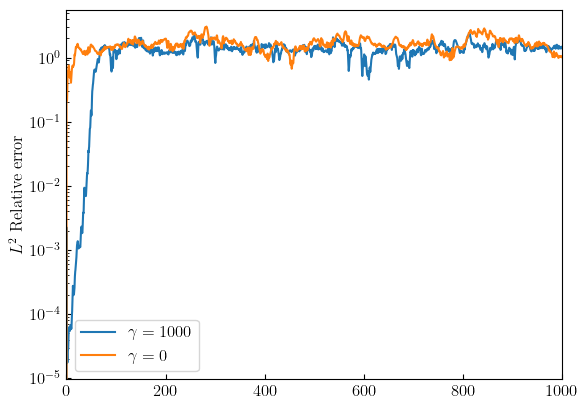

In [13]:
plt.plot(datasets["tau=0.001"]["tn"][::100], err_1, label=r"$\gamma = 1000$")
plt.plot(datasets["tau=0.001"]["tn"][::100], err_2, label=r"$\gamma = 0$")
plt.yscale("log")
plt.ylabel(r"$L^2$ Relative error")
plt.xlim(0,1000)
plt.legend()